### Mutual Correlation Energy, Orbital Energy Decomposition

In [19]:
import forte2
import numpy as np

In [2]:
from mutual_correlation_energy import fragment_decomposition_energy_enumerated
from mutual_correlation_energy import onefrag_correlation_energy_enumerated, twofrag_correlation_energy_enumerated, threefrag_correlation_energy_enumerated, fourfrag_correlation_energy_enumerated

import mutual_correlation_energy_mod as mcmod

In [3]:
xyz = """
H 0.000 0.000 0.000
H 0.000 0.000 1.740
H 0.000 0.000 3.480
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVDZ", auxiliary_basis_set="cc-pVTZ-JKFIT")

rhf = forte2.ROHF(charge=0,ms=0.5)(system)
rhf.run()

ci=forte2.CI(forte2.State(system=system, multiplicity=2,ms=0.5),active_orbitals=[0,1,2,3,4,5,6,7])(rhf)
ci.run()

fragments = [[0, 1], [2, 3], [4, 5], [6, 7]]

result = fragment_decomposition_energy_enumerated(ci, fragments)

print("CI energy:           ", result["ci_energy"])
print("Decomposition energy:", result["decomposition_energy"])
print("Residual:            ", result["residual"])

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   0.00000000   3.28812346
   H   0.00000000   0.00000000   6.57624691
Parsed 3 atoms with basis set of 15 functions.
  Max eigenvalue: 2.532e+00
  Min eigenvalue: 1.284e-01
  Condition number: 1.972e+01
  Inverse condition number: 5.071e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 15
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.284e-01
Number of electrons: 3
Number of alpha electrons: 2
Number of beta electrons: 1
Ms: 0.5
Total charge: 0
Number of basis functions: 15
Number of orthogonalized basis functions: 15
Number of auxiliary basis functions: 90
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis fun

In [4]:
xyz = """
H 0.000 0.000 0.000
H 0.000 0.000 1.740
"""
system = forte2.System(xyz=xyz, basis_set="cc-pVDZ", auxiliary_basis_set="cc-pVTZ-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci=forte2.CI(forte2.State(system=system, multiplicity=1,ms=0.0),active_orbitals=[0,1,2,3,4,5,6,7])(rhf)
ci.run()

fragments = [[0, 1], [2, 3], [4, 5], [6, 7]]

result = fragment_decomposition_energy_enumerated(ci, fragments)

print("CI energy:           ", result["ci_energy"])
print("Decomposition energy:", result["decomposition_energy"])
print("Residual:            ", result["residual"])

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   0.00000000   3.28812346
Parsed 2 atoms with basis set of 10 functions.
  Max eigenvalue: 2.268e+00
  Min eigenvalue: 1.969e-01
  Condition number: 1.152e+01
  Inverse condition number: 8.683e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 10
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.969e-01
Number of electrons: 2
Number of alpha electrons: 1
Number of beta electrons: 1
Ms: 0
Total charge: 0
Number of basis functions: 10
Number of orthogonalized basis functions: 10
Number of auxiliary basis functions: 60
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 10
Number of auxiliary basis functions:

In [5]:
xyz = """
H 0.000 0.000 -1.740
H 0.000 0.000 0.000
H 0.000 0.000 1.740
H 0.000 0.000 3.480
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=1.0)(system)
rhf.run()

ci=forte2.CI(forte2.State(system=system, multiplicity=3,ms=1.0),active_orbitals=[0,1,2,3,4,5,6,7])(rhf)
ci.run()


frag_orbs = [0,1,2,3,4,5,6,7]

ints = forte2.jkbuilder.RestrictedMOIntegrals(
    system=ci.system,
    C=ci.C[0],
    orbitals=frag_orbs,
    core_orbitals=(),
)

Ecore = ints.E

E_A = onefrag_correlation_energy_enumerated(ci, [0,1])
E_B = onefrag_correlation_energy_enumerated(ci, [2,3])
E_C = onefrag_correlation_energy_enumerated(ci, [4,5])
E_D = onefrag_correlation_energy_enumerated(ci, [6,7])

E_AB = twofrag_correlation_energy_enumerated(ci, [0,1],[2,3])
E_AC = twofrag_correlation_energy_enumerated(ci, [0,1],[4,5])
E_AD = twofrag_correlation_energy_enumerated(ci, [0,1],[6,7])
E_BC = twofrag_correlation_energy_enumerated(ci, [2,3],[4,5])
E_BD = twofrag_correlation_energy_enumerated(ci, [2,3],[6,7])
E_CD = twofrag_correlation_energy_enumerated(ci, [4,5],[6,7])

E_ABC = threefrag_correlation_energy_enumerated(ci, [0,1],[2,3],[4,5])
E_ABD = threefrag_correlation_energy_enumerated(ci, [0,1],[2,3],[6,7])
E_ACD = threefrag_correlation_energy_enumerated(ci, [0,1],[4,5],[6,7])
E_BCD = threefrag_correlation_energy_enumerated(ci, [2,3],[4,5],[6,7])

E_ABCD = fourfrag_correlation_energy_enumerated(ci, [0,1],[2,3],[4,5],[6,7])

print(ci.E - Ecore - E_A - E_B -E_C -E_D -E_AB -E_AC - E_AD -E_BC -E_BD -E_CD -E_ABC -E_ABD -E_ACD - E_BCD)
print(E_ABCD)

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   -3.28812346
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   0.00000000   3.28812346
   H   0.00000000   0.00000000   6.57624691
Parsed 4 atoms with basis set of 56 functions.
  Max eigenvalue: 3.509e+00
  Min eigenvalue: 3.574e-02
  Condition number: 9.818e+01
  Inverse condition number: 1.019e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 56
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 3.574e-02
Number of electrons: 4
Number of alpha electrons: 3
Number of beta electrons: 1
Ms: 1.0
Total charge: 0
Number of basis functions: 56
Number of orthogonalized basis functions: 56
Number of auxiliary basis functions: 72
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due

In [6]:
xyz = """
H 0.000 0.000 -1.740
H 0.000 0.000 0.000
H 0.000 0.000 1.740
H 0.000 0.000 3.480
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=1.0)(system)
rhf.run()

ci=forte2.CI(forte2.State(system=system, multiplicity=3,ms=1.0),active_orbitals=[0,1,2,3,4,5,6,7])(rhf)
ci.run()


frag_orbs = [0,1,2,3,4,5,6,7]

ints = forte2.jkbuilder.RestrictedMOIntegrals(
    system=ci.system,
    C=ci.C[0],
    orbitals=frag_orbs,
    core_orbitals=(),
)

e = ints.E #core energy

for i in frag_orbs:
    e += onefrag_correlation_energy_enumerated(ci, [i])
    for j in frag_orbs:
        if j<i:
            e += twofrag_correlation_energy_enumerated(ci, [i], [j])
            for k in frag_orbs:
                if k<j:
                    e += threefrag_correlation_energy_enumerated(ci, [i], [j], [k])
                    for l in frag_orbs:
                        if l<k:
                            e += fourfrag_correlation_energy_enumerated(ci, [i], [j], [k], [l])

print(ci.E)
print(e)


Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   -3.28812346
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   0.00000000   3.28812346
   H   0.00000000   0.00000000   6.57624691
Parsed 4 atoms with basis set of 56 functions.
  Max eigenvalue: 3.509e+00
  Min eigenvalue: 3.574e-02
  Condition number: 9.818e+01
  Inverse condition number: 1.019e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 56
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 3.574e-02
Number of electrons: 4
Number of alpha electrons: 3
Number of beta electrons: 1
Ms: 1.0
Total charge: 0
Number of basis functions: 56
Number of orthogonalized basis functions: 56
Number of auxiliary basis functions: 72
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due

#### two frag visualization (adapted MCA code)

In [7]:
from plot_correlation_energy import mutual_correlation_plot

In [8]:
xyz = """
H 0.000 0.000 0.000
H 0.000 0.740 0.000
"""

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

orb_list = [0,1,2,3,4,5,6,7,8,9]

hci=forte2.CI(forte2.State(system=system, multiplicity=1,ms=0),active_orbitals=orb_list)(rhf)
hci.run()

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   H   0.00000000   0.00000000   0.00000000
   H   0.00000000   1.39839733   0.00000000
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 4.217e+00
  Min eigenvalue: 1.591e-03
  Condition number: 2.650e+03
  Inverse condition number: 3.774e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.591e-03
Number of electrons: 2
Number of alpha electrons: 1
Number of beta electrons: 1
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28
Number of auxiliary basis functions: 36
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis functions:

CI(states=State(multiplicity=1, ms=0, nel=2, system=System(atoms=[[1, array([0., 0., 0.])], [1, array([0.        , 1.39839733, 0.        ])]], basis_set=<Basis 'cc-pVTZ' with 28 basis functions>, auxiliary_basis_set=<Basis 'def2-universal-JKFIT' with 36 basis functions>), charge=0, gas_min=[], gas_max=[], symmetry=0, symmetry_label=None, na=1, nb=1, twice_ms=0), nroots=1, weights=[[1.0]], mo_space=MOSpace(nmo=28, active_orbitals=[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]], core_orbitals=[], frozen_core_orbitals=[], frozen_virtual_orbitals=[]), frozen_core_orbitals=None, core_orbitals=None, active_orbitals=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], frozen_virtual_orbitals=None, die_if_not_converged=True, first_run=False, executed=True, ci_params=CIParams(ci_algorithm='hz', ci_builder_memory=1024, energy_shift=None), davidson_liu_params=DavidsonLiuParams(guess_per_root=2, ndets_per_guess=10, collapse_per_root=2, basis_per_root=4, maxiter=100, e_tol=1e-12, r_tol=1e-06), do_test_rdms=False, log_level=3, final_o

In [ ]:
MCEmat = mcmod.MutualCorrelationEnergyAnalysis(hci, 
nat_orbs=True, nocc=2
)
print(MCEmat.mutual_correlation_matrix_summary())

Total Correlation Energy (Sum of the 2-Cumulant Terms):    -0.0558474411

M2 Terms (|value| > 7.5e-04)
------------------------------------------
       0        2    -0.0198301031
       0        4    -0.0104852828
       0        5    -0.0104852828
       0        3    -0.0102521700
       0        1    -0.0079313029
       1        2     0.0030444210



Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 40 x 47 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



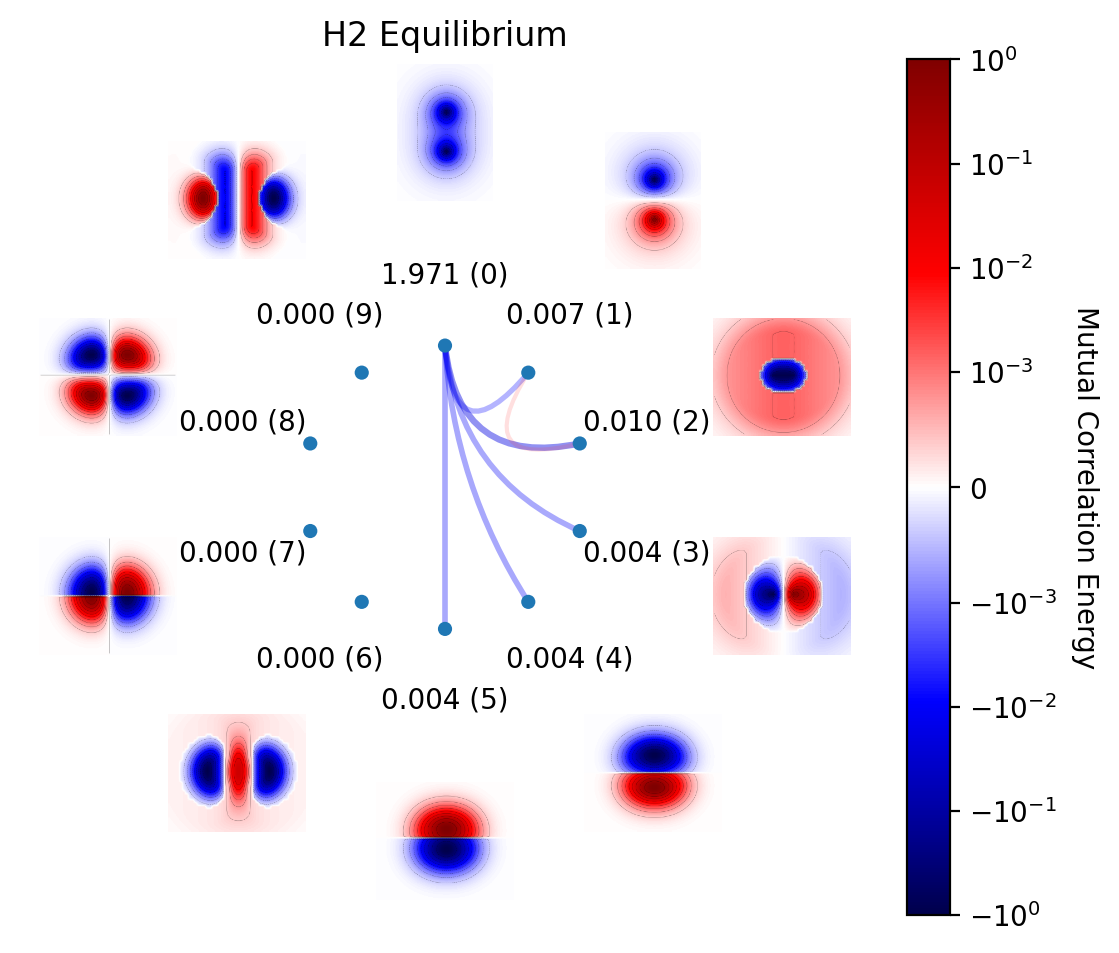

Forte2-computed natural orbital occupancies:

[[1.97073044e+00]
 [1.75968569e-02]
 [4.26089946e-03]
 [3.58299907e-03]
 [3.58299907e-03]
 [8.64009616e-05]
 [8.64009616e-05]
 [5.57979246e-05]
 [1.37009351e-05]
 [3.50946304e-06]]

MCE block-diagonal orbital rotation natural orbital occupancies:

1.9706214006160652
0.007293290583477041
0.010316978292745143
0.004339485992871151
0.0035829990679326273
0.0035829990679326256
8.64009615798651e-05
8.64009615798643e-05
8.624599399150548e-05
3.7984618262167065e-06

[1.97073044e+00 1.75968569e-02 4.26089946e-03 3.58299907e-03
 3.58299907e-03 8.64009616e-05 8.64009616e-05 5.57979246e-05
 1.37009351e-05 3.50946304e-06]
[1.97073044e+00 1.75968569e-02 4.26089946e-03 3.58299907e-03
 3.58299907e-03 8.64009616e-05 8.64009616e-05 5.57979246e-05
 1.37009351e-05 3.50946304e-06]


In [16]:
mutual_correlation_plot(system,hci.C[0],
                        indices=hci.active_indices,
                        mca=MCEmat,
                        title="H2 Equilibrium",
                        #occupation_numbers=hci.nat_occs,
                        output_file='h2_2cmod'
                        )

print("Forte2-computed natural orbital occupancies:")
print("")
print(hci.nat_occs)
print("")

print("MCE block-diagonal orbital rotation natural orbital occupancies:")
print("")
for i in range(len(MCEmat.gamma1[0])):
    print(MCEmat.gamma1[i][i])


#Check eigenvalues of orbital rotation:
print("")
w, _ = np.linalg.eigh(MCEmat.gamma1)
print(np.sort(w)[::-1])
print(hci.nat_occs.ravel())

gamma = mcmod._spin_summed_1rdm(hci)

w_ref = np.sort(np.linalg.eigvalsh(gamma))[::-1]
w_rot = np.sort(np.linalg.eigvalsh(MCEmat.gamma1))[::-1]

assert np.allclose(w_ref, w_rot)

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   B   0.00000000   0.00000000   0.00000000
   B   0.00000000   3.00466454   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 4.168e+00
  Min eigenvalue: 1.028e-03
  Condition number: 4.055e+03
  Inverse condition number: 2.466e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.028e-03
Number of electrons: 10
Number of alpha electrons: 6
Number of beta electrons: 4
Ms: 1.0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 150
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis funct

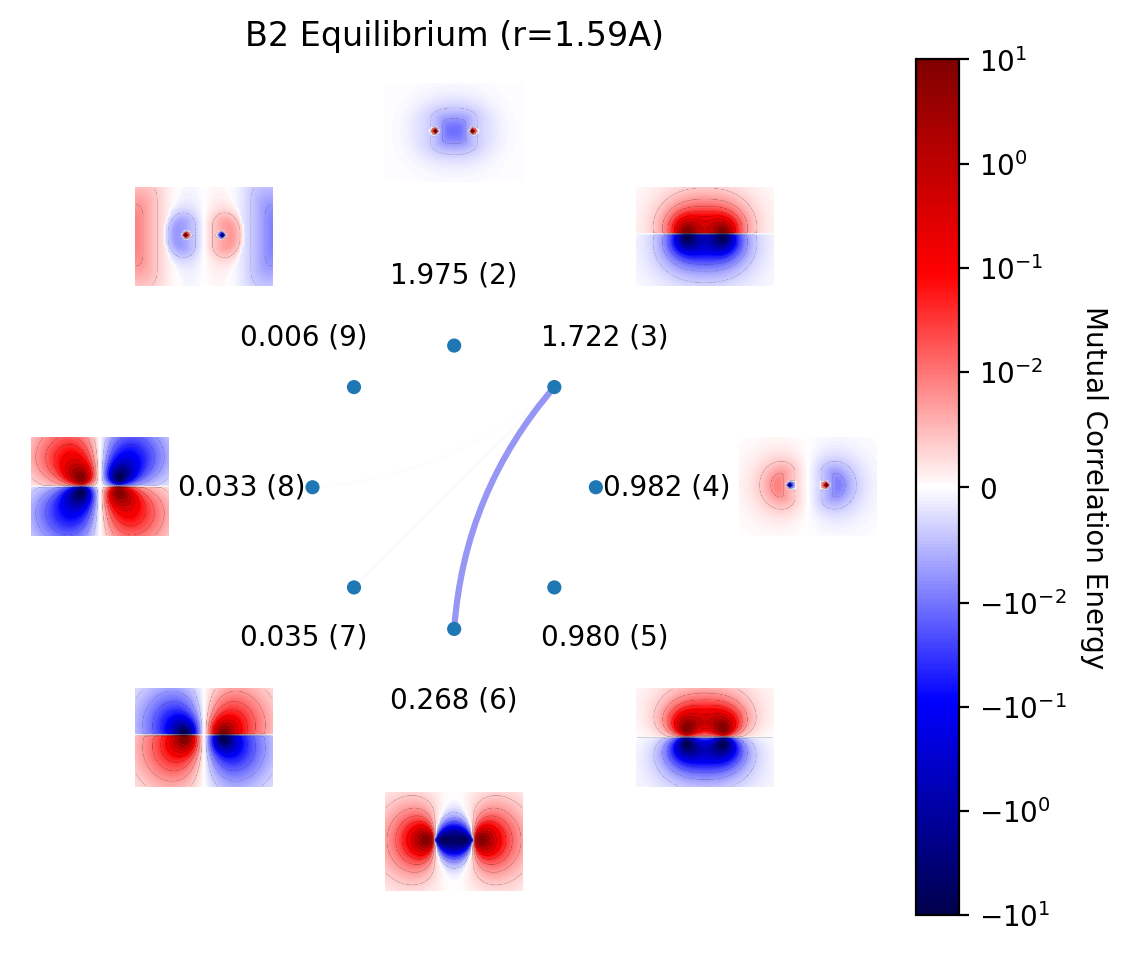

Total Correlation Energy (Sum of the 2-Cumulant Terms):    -0.1938303033

M2 Terms (|value| > 7.5e-04)
------------------------------------------
       3        6    -0.1703121001
       3        7    -0.0118750049
       3        8    -0.0107316244
       5        6    -0.0057115799
       4        6    -0.0053417114
       6        7     0.0050552731
       6        8     0.0045636090
       5        7    -0.0044279904
       3        5     0.0043631315
       3        4     0.0040757286
       4        8    -0.0040683254
       2        6    -0.0033703277
       2        3     0.0033048033
       2        7    -0.0023310663
       2        8    -0.0020194252
       2        5    -0.0017929619
       2        4    -0.0017082132
       4        5     0.0013118723
       3        9    -0.0012071930
       4        7    -0.0010302356
       5        8    -0.0009931284
       7        8     0.0008675769


In [18]:
xyz="""
B 0.000 0.000 0.000 
B 0.000 1.590 0.000
"""
orb_list = [2,3,4,5,6,7,8,9]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=1.0)(system)
rhf.run()

ci = forte2.CI(forte2.State(nel=10, multiplicity=3, ms=1.0),
    active_orbitals=orb_list,core_orbitals=[0,1])(rhf)
ci.run()

MCEmat = mcmod.MutualCorrelationEnergyAnalysis(ci=ci, nat_orbs=True, nocc=4)

mutual_correlation_plot(system,ci.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="B2 Equilibrium (r=1.59A)",
                        vmax=10,
                        #occupation_numbers=ci.nat_occs,
                        output_file='b2_eq_2cmod'
                        )
print(MCEmat.mutual_correlation_matrix_summary())

In [20]:
xyz="""
C 0.000 0.000 0.000 
C 0.000 1.2545 0.000
"""
orb_list = [2,3,4,5,6,7,8,9]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

avas=forte2.AVAS(selection_method='total',
                 num_active=8,
                 subspace=['C(2s)','C(2p)'])(rhf)

ci = forte2.CISolver(forte2.State(system=system, multiplicity=1, ms=0.0))
mc = forte2.MCOptimizer(ci)(avas)
mc.run()

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   C   0.00000000   0.00000000   0.00000000
   C   0.00000000   2.37066142   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 4.146e+00
  Min eigenvalue: 9.478e-04
  Condition number: 4.374e+03
  Inverse condition number: 2.286e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 9.478e-04
Number of electrons: 12
Number of alpha electrons: 6
Number of beta electrons: 6
Ms: 0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 150
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis function

MCOptimizer(ci_solver=CISolver(states=State(multiplicity=1, ms=0.0, nel=12, system=System(atoms=[[6, array([0., 0., 0.])], [6, array([0.        , 2.37066142, 0.        ])]], basis_set=<Basis 'cc-pVTZ' with 60 basis functions>, auxiliary_basis_set=<Basis 'def2-universal-JKFIT' with 150 basis functions>), charge=0, gas_min=[], gas_max=[], symmetry=0, symmetry_label=None, na=6, nb=6, twice_ms=0), nroots=1, weights=[[1.0]], mo_space=MOSpace(nmo=60, active_orbitals=[[2, 3, 4, 5, 6, 7, 8, 9]], core_orbitals=[0, 1], frozen_core_orbitals=[], frozen_virtual_orbitals=[]), frozen_core_orbitals=None, core_orbitals=None, active_orbitals=None, frozen_virtual_orbitals=None, die_if_not_converged=False, first_run=False, executed=True, ci_params=CIParams(ci_algorithm='hz', ci_builder_memory=1024, energy_shift=None), davidson_liu_params=DavidsonLiuParams(guess_per_root=2, ndets_per_guess=10, collapse_per_root=2, basis_per_root=4, maxiter=100, e_tol=1e-12, r_tol=1e-06), do_test_rdms=False, log_level=4), a

Total Correlation Energy (Sum of the 2-Cumulant Terms):    -0.3158862796

M2 Terms (|value| > 7.5e-04)
------------------------------------------
       5        6    -0.3133062137
       4        7    -0.0667837185
       3        8    -0.0667837183
       5        7    -0.0235115985
       5        8    -0.0235115985
       6        8     0.0186177055
       6        7     0.0186177055
       4        6    -0.0179392524
       3        6    -0.0179392524
       3        5     0.0174577497
       4        5     0.0174577497
       3        7    -0.0143018893
       4        8    -0.0143018893
       2        9    -0.0140554996
       7        8     0.0110238950
       3        4     0.0108940639
       2        7    -0.0043976008
       2        8    -0.0043976008
       2        6    -0.0043490437
       2        3     0.0040498415
       2        4     0.0040498415
       3        9    -0.0036279409
       4        9    -0.0036279409
       8        9     0.0027344130
       7      

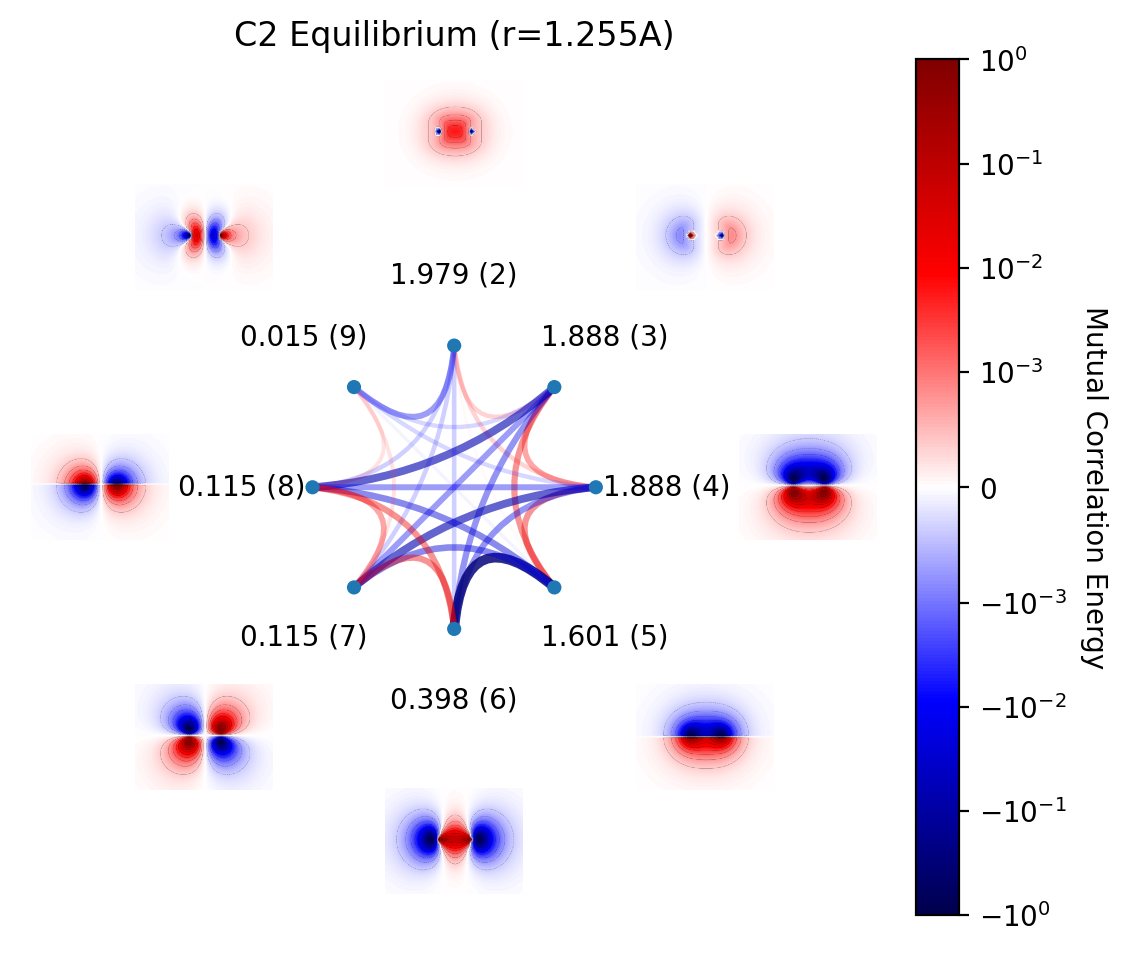

In [21]:
MCEmat = mcmod.MutualCorrelationEnergyAnalysis(ci=ci, 
                                               nat_orbs=True, nocc=4
                                               )
# MCEmat = np.zeros((len(orb_list),len(orb_list)))
# for i in range(len(orb_list)):
#     for j in range(len(orb_list)):
#         if j>i:
#             MCEmat[i][j] = twofrag_correlation_energy_enumerated(ci=ci, A_orbs=[orb_list[i]], B_orbs=[orb_list[j]])

print(MCEmat.mutual_correlation_matrix_summary())

mutual_correlation_plot(system,ci.C[0],
                        indices=ci.active_indices,
                        mca=MCEmat,
                        title="C2 Equilibrium (r=1.255A)",
                        #vmax=10,
                        occupation_numbers=ci.nat_occs, #only do this if nat_orbs = True in mce analysis
                        output_file='c2_eq_2cmod'
                        )

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   N   0.00000000   0.00000000   0.00000000
   N   0.00000000   2.07435237   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 4.073e+00
  Min eigenvalue: 1.153e-03
  Condition number: 3.534e+03
  Inverse condition number: 2.830e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.153e-03
Number of electrons: 14
Number of alpha electrons: 7
Number of beta electrons: 7
Ms: 0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 154
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis function

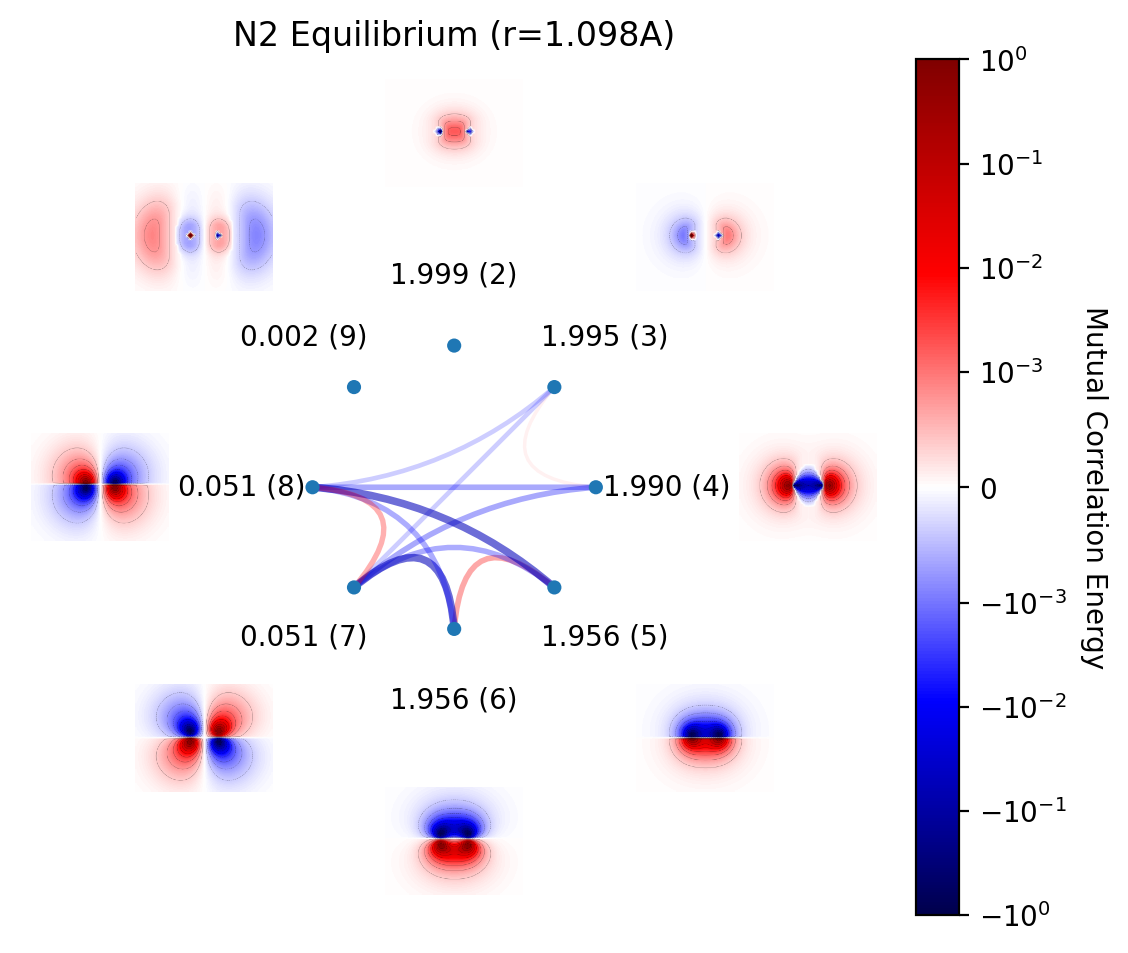

In [22]:
xyz="""
N 0.000 0.000 0.000 
N 0.000 1.0977 0.000
"""
orb_list = [2,3,4,5,6,7,8,9]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci = forte2.CI(forte2.State(nel=14, multiplicity=1, ms=0.0),
    active_orbitals=orb_list,core_orbitals=[0,1])(rhf)
ci.run()

MCEmat = mcmod.MutualCorrelationEnergyAnalysis(ci=ci, nat_orbs=True, nocc=5)
# MCEmat = np.zeros((len(orb_list),len(orb_list)))
# for i in range(len(orb_list)):
#     for j in range(len(orb_list)):
#         if j>i:
#             MCEmat[i][j] = twofrag_correlation_energy_enumerated(ci=ci, A_orbs=[orb_list[i]], B_orbs=[orb_list[j]])

mutual_correlation_plot(system,ci.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="N2 Equilibrium (r=1.098A)",
                        #vmax=1,
                        #occupation_numbers=ci.nat_occs,
                        output_file='n2_eq_2cmod_rescaled'
                        )
#print(MCEmat.mutual_correlation_matrix_summary())

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   N   0.00000000   0.00000000   0.00000000
   N   0.00000000   4.14870473   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 2.863e+00
  Min eigenvalue: 2.272e-02
  Condition number: 1.260e+02
  Inverse condition number: 7.936e-03
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 2.272e-02
Number of electrons: 14
Number of alpha electrons: 7
Number of beta electrons: 7
Ms: 0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 154
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis function

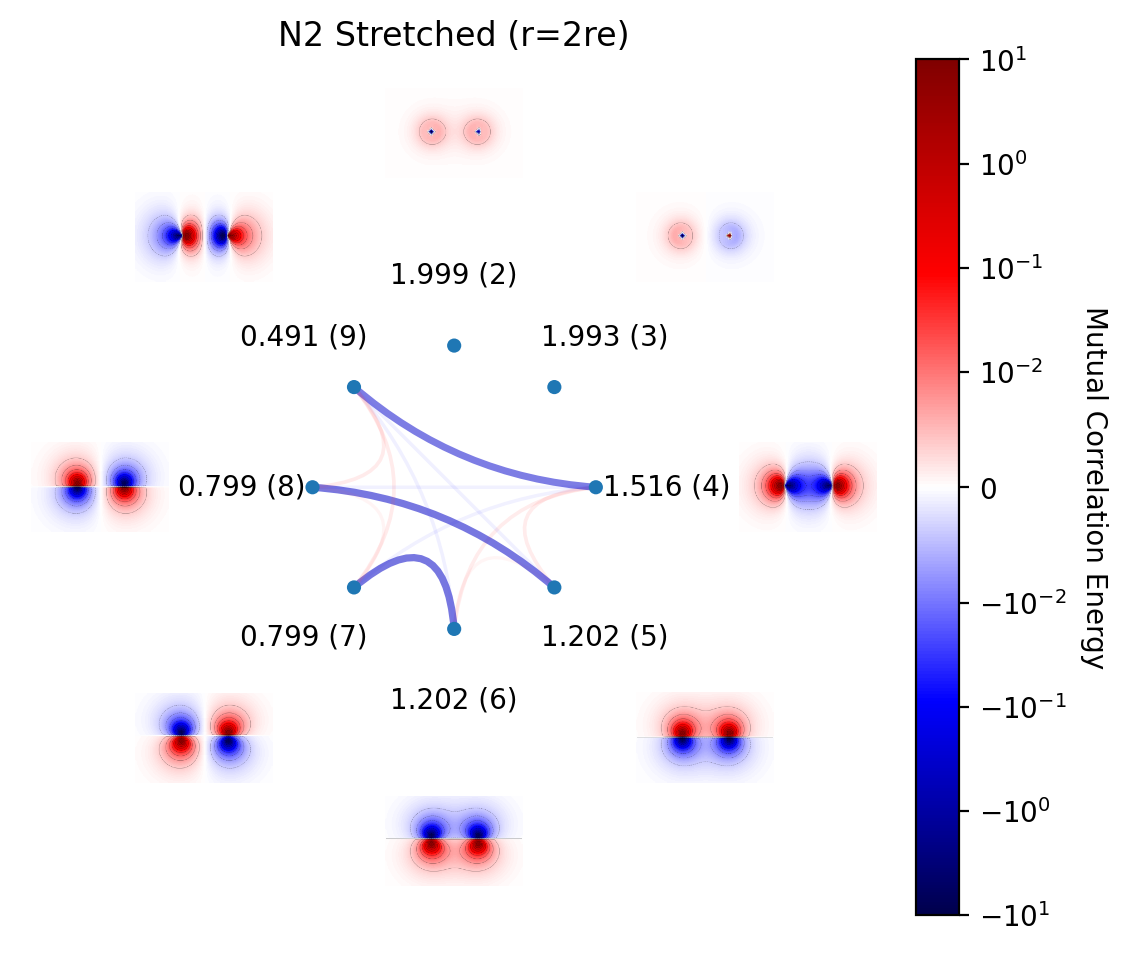

In [23]:
xyz="""
N 0.000 0.000 0.000 
N 0.000 2.1954 0.000
"""
orb_list = [2,3,4,5,6,7,8,9]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci = forte2.CI(forte2.State(nel=14, multiplicity=1, ms=0.0),
    active_orbitals=orb_list,core_orbitals=[0,1])(rhf)
ci.run()

MCEmat = mcmod.MutualCorrelationEnergyAnalysis(ci=ci, nat_orbs=True, nocc=5)
# MCEmat = np.zeros((len(orb_list),len(orb_list)))
# for i in range(len(orb_list)):
#     for j in range(len(orb_list)):
#         if j>i:
#             MCEmat[i][j] = twofrag_correlation_energy_enumerated(ci=ci, A_orbs=[orb_list[i]], B_orbs=[orb_list[j]])


mutual_correlation_plot(system,ci.C[0],
                        indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="N2 Stretched (r=2re)",
                        vmax=10,
                        #occupation_numbers=ci.nat_occs,
                        output_file='n2_stretched_2cmod'
                        )

#print(MCEmat.mutual_correlation_matrix_summary())

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   O   0.00000000   0.00000000   0.00000000
   O   0.00000000   2.28184430   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 3.735e+00
  Min eigenvalue: 4.428e-03
  Condition number: 8.434e+02
  Inverse condition number: 1.186e-03
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 4.428e-03
Number of electrons: 16
Number of alpha electrons: 9
Number of beta electrons: 7
Ms: 1.0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 154
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> ROHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis funct

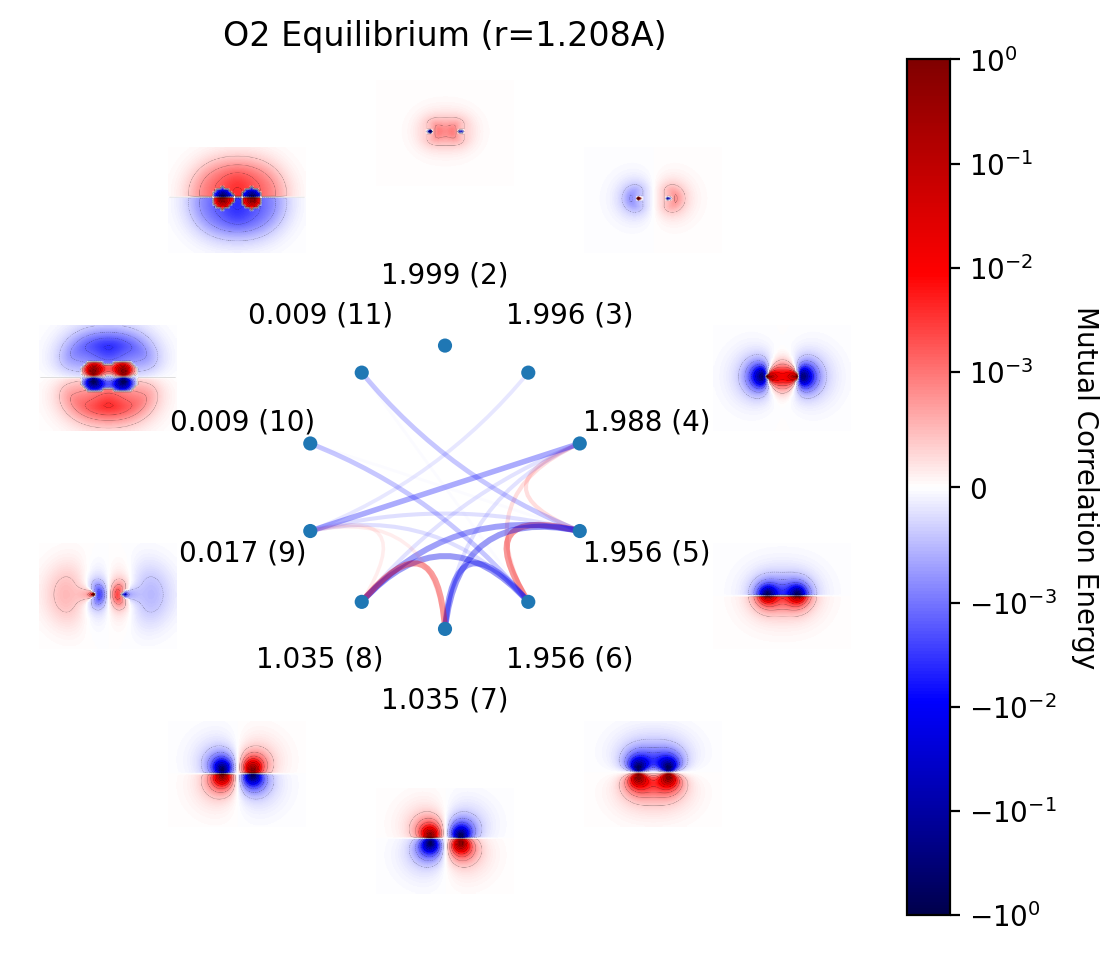

Total Correlation Energy (Sum of the 2-Cumulant Terms):    -0.1721297679

M2 Terms (|value| > 7.5e-04)
------------------------------------------
       5        6     0.0162575251
       5        7    -0.0149419717
       6        8    -0.0149419717
       7        8     0.0145951299
       5        8    -0.0131519747
       6        7    -0.0131519746
       4        9    -0.0098015964
       6       10    -0.0054285307
       5       11    -0.0054285307
       4        6     0.0030897192
       4        5     0.0030897192
       6        9    -0.0029219721
       5        9    -0.0029219721
       4        7    -0.0028257999
       4        8    -0.0028257999
       3        9    -0.0023551856
       7        9     0.0019811717
       8        9     0.0019811717
       6       11    -0.0011854164
       5       10    -0.0011854163
       2        9    -0.0009278046


In [27]:
xyz="""
O 0.000 0.000 0.000 
O 0.000 1.2075 0.000
"""
orb_list = [2,3,4,5,6,7,8,9,10,11]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.ROHF(charge=0, ms=1.0)(system)
rhf.run()

ci = forte2.CI(forte2.State(nel=16, multiplicity=3, ms=1.0),
    active_orbitals=orb_list,core_orbitals=[0,1])(rhf)
ci.run()

MCEmat = mcmod.MutualCorrelationEnergyAnalysis(ci=ci, nat_orbs=True, nocc=7)

mutual_correlation_plot(system,ci.C[0],indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="O2 Equilibrium (r=1.208A)",
                        #vmax=1,
                        #occupation_numbers=ci.nat_occs,
                        output_file='o2_eq_2cmod'
                        )

print(MCEmat.mutual_correlation_matrix_summary())

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   F   0.00000000   0.00000000   0.00000000
   F   0.00000000   2.66829329   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 3.206e+00
  Min eigenvalue: 1.535e-02
  Condition number: 2.089e+02
  Inverse condition number: 4.787e-03
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 1.535e-02
Number of electrons: 18
Number of alpha electrons: 9
Number of beta electrons: 9
Ms: 0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 154
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis function

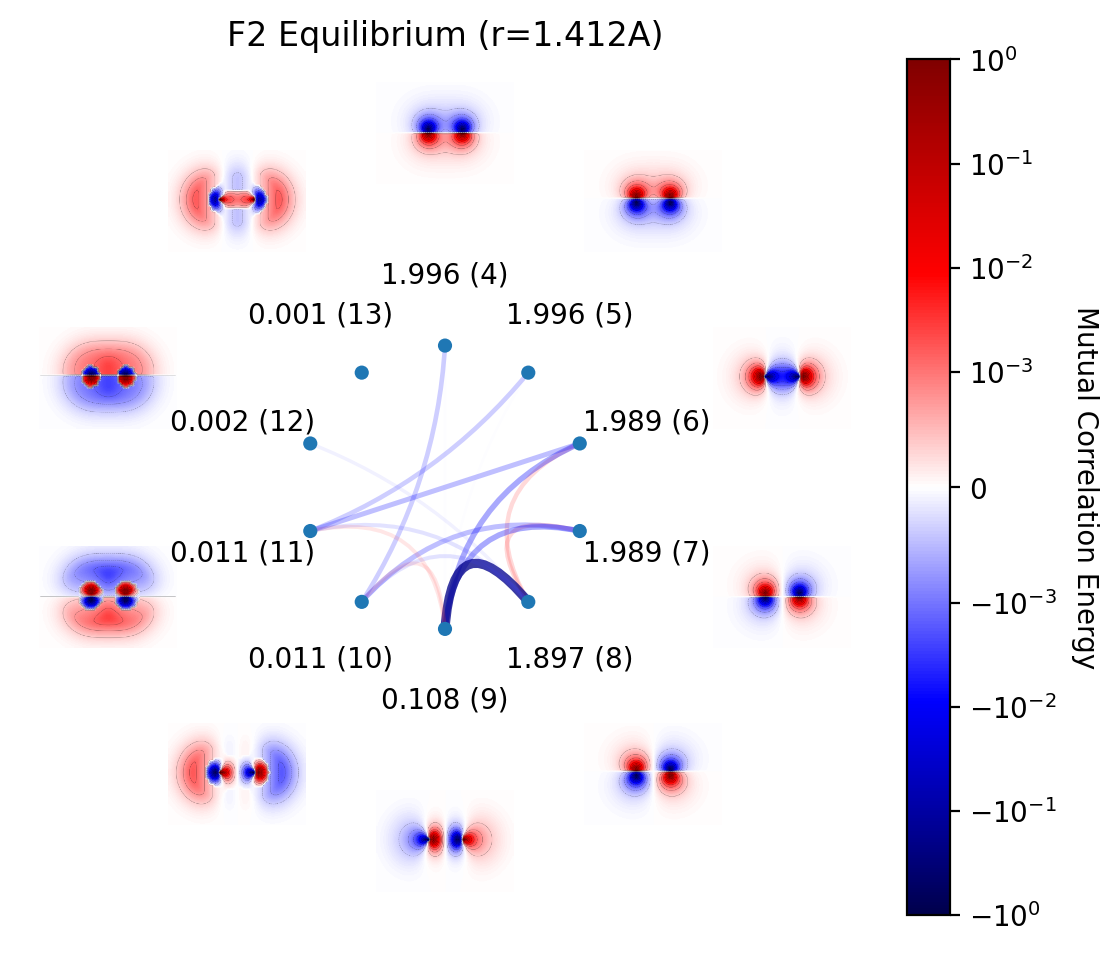

Total Correlation Energy (Sum of the 2-Cumulant Terms):    -0.2451302629

M2 Terms (|value| > 7.5e-04)
------------------------------------------
       8        9    -0.2047026829
       7        9    -0.0101803067
       6        9    -0.0101803038
       7       10    -0.0063605916
       6       11    -0.0063605916
       4       10    -0.0045442879
       5       11    -0.0045442879
       7        8     0.0035792596
       6        8     0.0035792595
       8       10    -0.0027395883
       8       11    -0.0027395883
       9       10     0.0024742361
       9       11     0.0024742361
       8       12    -0.0017446059
       5        9    -0.0010633313
       4        9    -0.0010633303
      10       11     0.0008106711
       6        7     0.0007934348
       5        6     0.0007519056
       4        7     0.0007519054


In [28]:
xyz="""
F 0.000 0.000 0.000 
F 0.000 1.412 0.000
"""
orb_list = [4,5,6,7,8,9,10,11,12,13]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci = forte2.CI(forte2.State(nel=18, multiplicity=1, ms=0.0),
    active_orbitals=orb_list,core_orbitals=[0,1,2,3])(rhf)
ci.run()

MCEmat = mcmod.MutualCorrelationEnergyAnalysis(ci=ci, nat_orbs=True, nocc=5)

mutual_correlation_plot(system,ci.C[0],indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="F2 Equilibrium (r=1.412A)",
                        #vmax=10,
                        #occupation_numbers=ci.nat_occs,
                        output_file='f2_eq_2cmod'
                        )
print(MCEmat.mutual_correlation_matrix_summary())

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   F   0.00000000   0.00000000   0.00000000
   F   0.00000000   5.66917837   0.00000000
Parsed 2 atoms with basis set of 60 functions.
  Max eigenvalue: 2.228e+00
  Min eigenvalue: 4.167e-02
  Condition number: 5.346e+01
  Inverse condition number: 1.870e-02
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 60
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 4.167e-02
Number of electrons: 18
Number of alpha electrons: 9
Number of beta electrons: 9
Ms: 0
Total charge: 0
Number of basis functions: 60
Number of orthogonalized basis functions: 60
Number of auxiliary basis functions: 154
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.01 GB (doubled due to storing B_nPm)
Number of system basis functions: 60
Number of auxiliary basis function

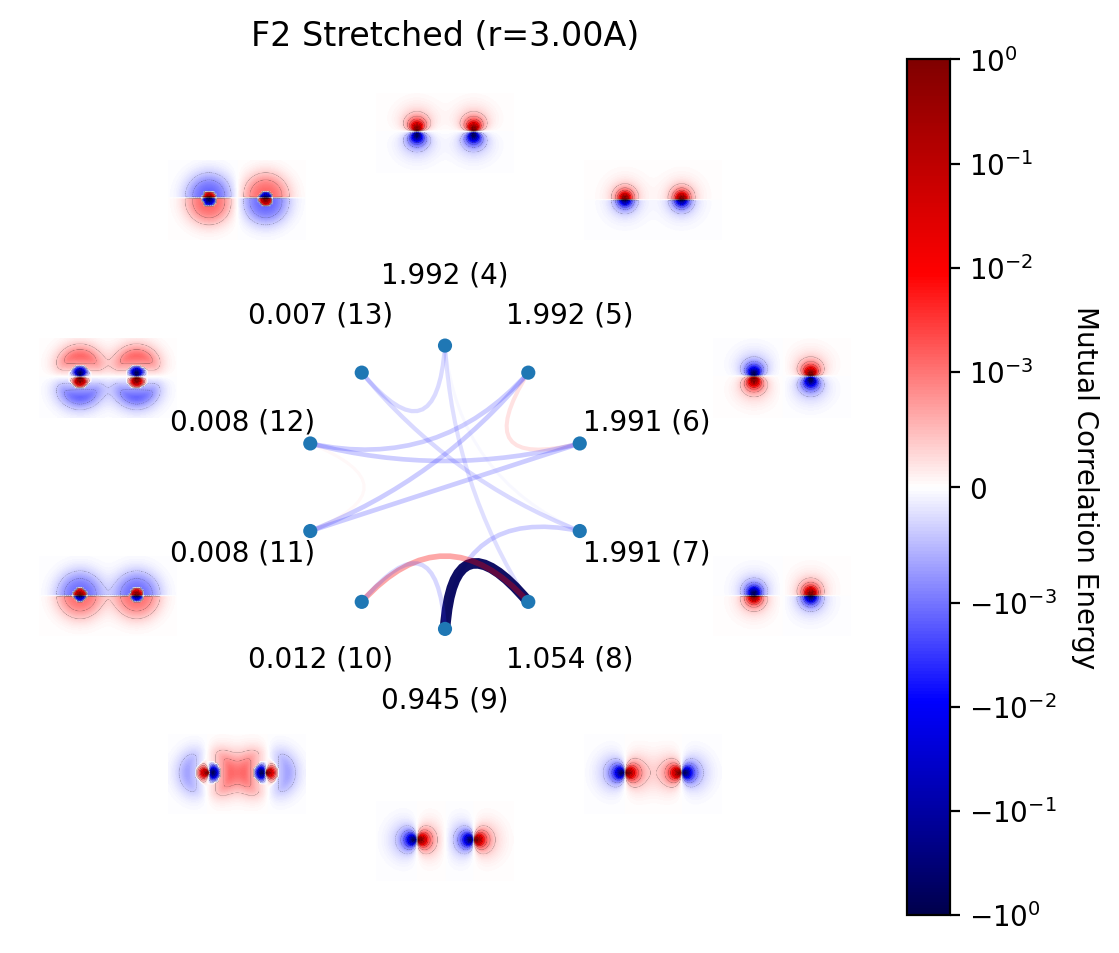

Total Correlation Energy (Sum of the 2-Cumulant Terms):    -0.5177558559

M2 Terms (|value| > 7.5e-04)
------------------------------------------
       8        9    -0.6659023298
       8       10     0.0108439961
       6       11    -0.0048627983
       5       11    -0.0048398754
       6       12    -0.0046982913
       5       12    -0.0045961197
       7        9    -0.0044326965
       9       10    -0.0037159395
       7       13    -0.0035316920
       4       13    -0.0033808162
       4        8    -0.0029820913
       5        6     0.0028251247
      11       12     0.0013480715
       4        7    -0.0013257055


In [29]:
xyz="""
F 0.000 0.000 0.000 
F 0.000 3.00 0.000
"""
orb_list = [4,5,6,7,8,9,10,11,12,13]

system = forte2.System(xyz=xyz, basis_set="cc-pVTZ", auxiliary_basis_set="def2-universal-JKFIT")

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci = forte2.CI(forte2.State(system=system, multiplicity=1, ms=0.0),
    active_orbitals=orb_list,core_orbitals=[0,1,2,3])(rhf)
ci.run()

MCEmat = mcmod.MutualCorrelationEnergyAnalysis(ci=ci, nat_orbs=True, nocc=5)

mutual_correlation_plot(system,ci.C[0],indices=ci.mo_space.active_indices,
                        mca=MCEmat,
                        title="F2 Stretched (r=3.00A)",
                        #vmax=10,
                        #occupation_numbers=ci.nat_occs,
                        output_file='f2_stretched_2cmod'
                        ) 
print(MCEmat.mutual_correlation_matrix_summary())

In [30]:
print(MCEmat.M1)

{(0,): np.float64(0.001307908920458345), (1,): np.float64(0.0006510839228768682), (2,): np.float64(0.0007475786193027777), (3,): np.float64(0.0016930222802198068), (4,): np.float64(0.12330876277911809), (5,): np.float64(0.13093065614249225), (6,): np.float64(2.013695672288485e-05), (7,): np.float64(0.00035963894409691936), (8,): np.float64(0.0003327597947199788), (9,): np.float64(0.00023794945291131497)}


In [31]:
print(MCEmat.ci.nat_occs[2][0])

1.991818650598974
